# **Model Trainer**

### *it is binary classification problem and we use almost all ML algorithm, to check which perform well and that be our base model and improve with help of hyperperameter tunning*

In [2]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix,classification_report
import warnings
warnings.filterwarnings('ignore')
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split


In [3]:
#loading data
df = pd.read_csv('Data\churn.csv')
df.head()

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [4]:
# getting X and y
X = df.iloc[:,:-1]
y = df['churn']

In [5]:
X.head()

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10


In [6]:
y

0       1
1       0
2       1
3       0
4       0
       ..
9995    0
9996    0
9997    1
9998    1
9999    0
Name: churn, Length: 10000, dtype: int64

In [7]:
# removing the customer_id 
X = X.drop('customer_id',axis =1)

In [8]:
# getting categorical and numerical column
X_num = X.select_dtypes(exclude='O').columns
X_num

Index(['credit_score', 'age', 'tenure', 'balance', 'products_number',
       'credit_card', 'active_member', 'estimated_salary'],
      dtype='str')

In [9]:
X_cate = X.select_dtypes(include='O').columns
X_cate

Index(['country', 'gender'], dtype='str')

In [10]:
from sklearn.compose import ColumnTransformer
sc = StandardScaler()
onh = OneHotEncoder(drop='first',sparse_output=False)
preprocessing = ColumnTransformer(
    [
        ('scaling',sc,X_num),
        ('encoding',onh,X_cate)
    ],remainder ='passthrough'
)


In [11]:
#splitting in test and train
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2,random_state =42)

In [12]:
#apply transformation
X_train = preprocessing.fit_transform(X_train)
X_test = preprocessing.transform(X_test)

## **Make class balance using SMOTE**

In [13]:
smote = SMOTE(random_state=42)
X_train_balance ,y_train_balance = smote.fit_resample(X_train,y_train)

## **MOdel Training**

#### **finding best model**

In [14]:
#getting performance of model
def evalute_model(true,pred):
    accuracy = accuracy_score(true,pred)
    f_score = f1_score(true,pred)
    recall= recall_score(true,pred)
    precision = precision_score(true,pred)

    return accuracy,f_score,recall,precision

LogisticRegression
Model performance for Training set
- Accuracy of Training: 0.7081
- F1_Score of Training: 0.7047
- Recall of Training: 0.6965
- Precision of Training: 0.7131
----------------------------------
Model performance for Test set
- Accuracy of Testing: 0.7290
- F1_Score of Testing: 0.5108
- Recall of Testing: 0.7201
- Precision of Testing: 0.3958


KNeighborsClassifier
Model performance for Training set
- Accuracy of Training: 0.9049
- F1_Score of Training: 0.9117
- Recall of Training: 0.9819
- Precision of Training: 0.8509
----------------------------------
Model performance for Test set
- Accuracy of Testing: 0.7450
- F1_Score of Testing: 0.5207
- Recall of Testing: 0.7048
- Precision of Testing: 0.4128


DecisionTreeClassifier
Model performance for Training set
- Accuracy of Training: 1.0000
- F1_Score of Training: 1.0000
- Recall of Training: 1.0000
- Precision of Training: 1.0000
----------------------------------
Model performance for Test set
- Accuracy of Testing: 

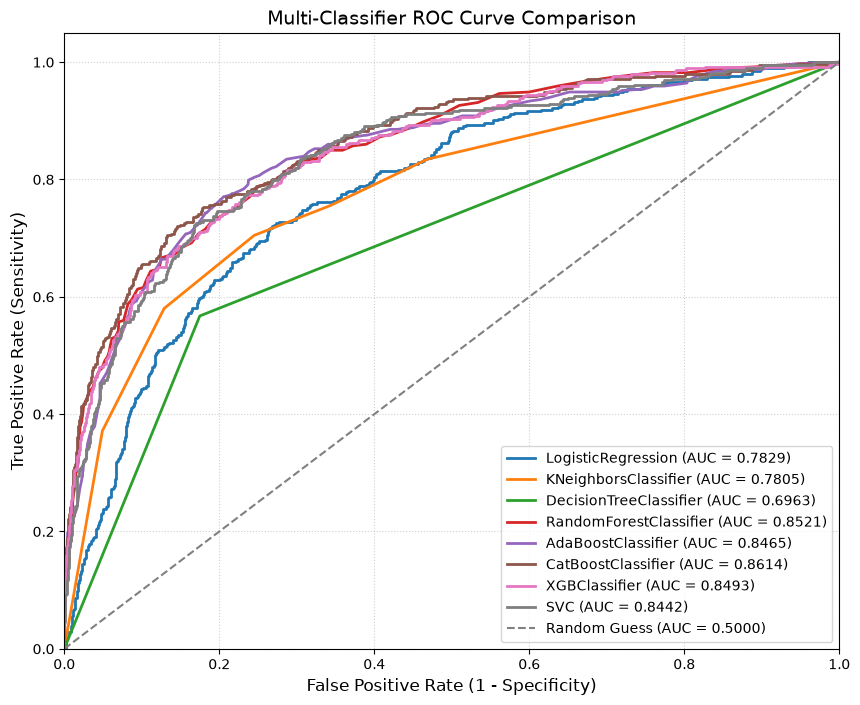

In [18]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

models = {
    'LogisticRegression': LogisticRegression(),
    'KNeighborsClassifier': KNeighborsClassifier(),
    'DecisionTreeClassifier': DecisionTreeClassifier(),
    'RandomForestClassifier': RandomForestClassifier(),
    'AdaBoostClassifier': AdaBoostClassifier(),
    'CatBoostClassifier': CatBoostClassifier(verbose=False),
    'XGBClassifier': XGBClassifier(),
    'SVC': SVC(probability=True) 
}

model_list = []
accuracy_list = []

plt.figure(figsize=(10, 8))

for name, model in models.items():
   
    model.fit(X_train_balance, y_train_balance) 

    y_train_pred = model.predict(X_train_balance)
    y_test_pred = model.predict(X_test)
    
    # Calculate probabilities for the positive class 
    y_test_probs = model.predict_proba(X_test)[:, 1]
    
    # Calculate ROC metrics and AUC score
    fpr, tpr, _ = roc_curve(y_test, y_test_probs)
    auc_score = roc_auc_score(y_test, y_test_probs)
    
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc_score:.4f})', lw=2)
    
    model_train_acc, model_train_f1, model_train_recal, model_train_pre = evalute_model(y_train_balance, y_train_pred)
    model_test_acc, model_test_f1, model_test_recal, model_test_pre = evalute_model(y_test, y_test_pred)
    
    print(name)
    model_list.append(name)
    accuracy_list.append(model_test_acc)
    
    print('Model performance for Training set')
    print("- Accuracy of Training: {:.4f}".format(model_train_acc))
    print("- F1_Score of Training: {:.4f}".format(model_train_f1))
    print("- Recall of Training: {:.4f}".format(model_train_recal))
    print("- Precision of Training: {:.4f}".format(model_train_pre))
    print('----------------------------------')
    print('Model performance for Test set')
    print("- Accuracy of Testing: {:.4f}".format(model_test_acc))
    print("- F1_Score of Testing: {:.4f}".format(model_test_f1))
    print("- Recall of Testing: {:.4f}".format(model_test_recal))
    print("- Precision of Testing: {:.4f}".format(model_test_pre))
    print('='*35)
    print('\n')

plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Guess (AUC = 0.5000)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Sensitivity)', fontsize=12)
plt.title('Multi-Classifier ROC Curve Comparison', fontsize=14)
plt.legend(loc="lower right")
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()


#### *interpretation*
- auc of CatBoostClassifier is 0.8614 means the CatBoost model has an 86.14% chance of correctly distinguishing between a positive class and a negative class.
- this is why i choose it

## **from the above models the CatboostClassifier perform well and show no overfitting and generalize good among the models**

*we have seen there was no good relation among the instances of feature with target column, there are problem in data where we are not getting good result*

# **HyperPerameter tunning**

In [34]:
param_grid = {
    "iterations": [500,700,1000],
    "learning_rate": [0.03,0.05,0.07,0.1],
    "depth": [4,5,6,7,8],
    "l2_leaf_reg": [1, 3, 5, 7, 9],
    "border_count": [32, 64, 128, 255],
    "bagging_temperature": [0, 1, 3, 5],
    "random_strength": [1, 5, 10],
    "bootstrap_type": ["Bayesian"],
    #"subsample": [0.6, 0.8, 1.0]
}
param_grid

{'iterations': [500, 700, 1000],
 'learning_rate': [0.03, 0.05, 0.07, 0.1],
 'depth': [4, 5, 6, 7, 8],
 'l2_leaf_reg': [1, 3, 5, 7, 9],
 'border_count': [32, 64, 128, 255],
 'bagging_temperature': [0, 1, 3, 5],
 'random_strength': [1, 5, 10],
 'bootstrap_type': ['Bayesian']}

In [35]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)
cat = CatBoostClassifier(verbose=False)
tune_model = RandomizedSearchCV(
    estimator=cat,
    param_distributions = param_grid,
    n_iter=75,
scoring= 'f1',
cv =cv,
verbose=2,
random_state=42,n_jobs=-1
)

In [36]:
tune_model.fit(X_train_balance,y_train_balance)
print("Best Parameters:")
print(tune_model.best_params_)

print("\nBest Score:")
print(tune_model.best_score_)

Fitting 5 folds for each of 75 candidates, totalling 375 fits
Best Parameters:
{'random_strength': 10, 'learning_rate': 0.07, 'l2_leaf_reg': 1, 'iterations': 1000, 'depth': 8, 'border_count': 255, 'bootstrap_type': 'Bayesian', 'bagging_temperature': 3}

Best Score:
0.9126205362521839


In [37]:
# Get the best model
best_model = tune_model.best_estimator_

prob = best_model.predict_proba(X_test)[:, 1]

best_threshold = 0
best_f1 = 0

for threshold in [i / 100 for i in range(20, 81, 5)]:
    y_pred = (prob >= threshold).astype(int)
    score = f1_score(y_test, y_pred)

    print(f"Threshold: {threshold:.2f} | F1: {score:.4f}")

    if score > best_f1:
        best_f1 = score
        best_threshold = threshold

print("\nBest Threshold:", best_threshold)
print("Best F1:", best_f1)

Threshold: 0.20 | F1: 0.5562
Threshold: 0.25 | F1: 0.5778
Threshold: 0.30 | F1: 0.5925
Threshold: 0.35 | F1: 0.6017
Threshold: 0.40 | F1: 0.5970
Threshold: 0.45 | F1: 0.5901
Threshold: 0.50 | F1: 0.5894
Threshold: 0.55 | F1: 0.5929
Threshold: 0.60 | F1: 0.5744
Threshold: 0.65 | F1: 0.5657
Threshold: 0.70 | F1: 0.5495
Threshold: 0.75 | F1: 0.5109
Threshold: 0.80 | F1: 0.4774

Best Threshold: 0.35
Best F1: 0.6016646848989299


#### **results of all models on test data**

In [19]:
best_acc =pd.DataFrame(list(zip(model_list,accuracy_list )), 
                       columns=['Model Name', 'Accuracy']).sort_values(by=["Accuracy"],ascending=False)
best_acc

,Model Name,Accuracy
5,CatBoostClassifier,0.8600
3,RandomForestClassifier,0.8525
6,XGBClassifier,0.8515
4,AdaBoostClassifier,0.8035
7,SVC,0.7935
2,DecisionTreeClassifier,0.7745
1,KNeighborsClassifier,0.7450
0,LogisticRegression,0.7290


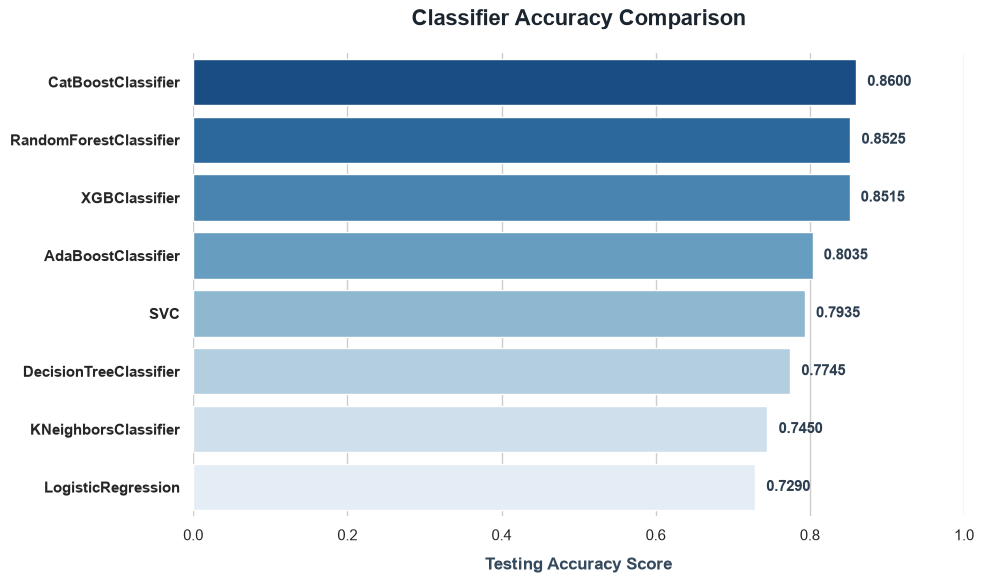

In [21]:
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

ax = sns.barplot(
    x='Accuracy', 
    y='Model Name', 
    data=best_acc, 
    palette='Blues_r',  
    hue='Model Name',   
    legend=False
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.4f', padding=8, fontsize=11, weight='bold', color='#2c3e50')

sns.despine(left=True, bottom=True)
plt.xlim(0, 1.0)  # Standard 0% to 100% scale

plt.title('Classifier Accuracy Comparison', fontsize=16, pad=20, weight='bold', color='#1a252f')
plt.xlabel('Testing Accuracy Score', fontsize=12, labelpad=10, weight='bold', color='#34495e')
plt.ylabel('', fontsize=12) 
plt.xticks(fontsize=11)
plt.yticks(fontsize=11, weight='bold')

plt.tight_layout()
plt.show()


### *CatBoostClassifier generalize better on unseen data and give high f1_score and precision recall**